<a href="https://colab.research.google.com/github/sameh-mo/disease-risk-prediction/blob/main/Liver_Disease_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

# 📌 **Introduction**

The goal of this project is to build a machine learning model that can accurately predict liver disease based on patient medical attributes. Early detection of liver disease is important for improving treatment outcomes and reducing health risks.

In this project, two machine learning algorithms will be used: **K-Nearest Neighbors (KNN)** and **Decision Tree**. The performance of both models will be compared to determine the most suitable approach for this dataset.

The workflow of the project includes:

Data collection and loading from a real-world dataset.
Exploratory Data Analysis (EDA) to understand the structure and patterns in the data.
Data preprocessing including handling missing values and encoding categorical variables.
Splitting the data into training, validation, and testing sets.
Building and evaluating machine learning models.

The final objective is to develop a reliable classification model that can assist in predicting liver disease with good accuracy and generalization ability.

The dataset contains demographic, lifestyle, clinical, and laboratory features used to predict liver disease classification.

| Column Name            | Description                                     |
| ---------------------- | ----------------------------------------------- |
| Age                    | Age of the individual (in years)                |
| Gender                 | Biological sex of the individual                |
| Occupation             | Job or profession category                      |
| BMI                    | Body Mass Index (weight/height²)                |
| Obesity_Class          | Classification of obesity level                 |
| Waist_Circumference    | Waist measurement (cm)                          |
| Diet_Quality           | Quality of diet (e.g., good/average/poor)       |
| Physical_Activity      | Level of physical activity                      |
| Sleep_Hours            | Average daily sleep duration (hours)            |
| Smoking_Status         | Smoking behavior status                         |
| Alcohol_Consumption    | Alcohol usage pattern                           |
| Sym_Fatigue            | Presence of fatigue symptoms (0/1)              |
| Sym_Jaundice           | Presence of jaundice symptoms (0/1)             |
| Sym_Abdominal_Pain     | Presence of abdominal pain (0/1)                |
| Sym_Itching            | Presence of itching (0/1)                       |
| Sym_Ascites            | Presence of ascites (fluid in abdomen) (0/1)    |
| Sym_Dark_Urine         | Presence of dark urine symptom (0/1)            |
| Sym_Weight_Loss        | Presence of unexplained weight loss (0/1)       |
| Comorb_Diabetes        | Presence of diabetes (0/1)                      |
| Comorb_Hypertension    | Presence of hypertension (0/1)                  |
| Comorb_Genetic_History | Family history of liver disease (0/1)           |
| ALT                    | Alanine Aminotransferase level (liver enzyme)   |
| AST                    | Aspartate Aminotransferase level (liver enzyme) |
| Bilirubin              | Bilirubin level in blood                        |
| Albumin                | Blood albumin level                             |
| Platelets              | Platelet count                                  |
| Alk_Phosphatase        | Alkaline phosphatase enzyme level               |
| GGT                    | Gamma-glutamyl transferase enzyme level         |
| Triglycerides          | Blood triglyceride level                        |
| INR                    | Blood clotting index                            |
| Source                 | Data source identifier                          |
| Liver_Disease_Class    | Target variable indicating liver disease class  |


# 🧹 **1.Prepare Date**

## 1.1 Import

In [6]:
# download dataset form kaggel
path = kagglehub.dataset_download("priyankabarik/liver-diseases")

# file name
file_name_training = "Training_Liver_Disease_Dataset.csv"
file_name_testing = "Testing_Liver_Disease_Dataset.csv"

# loading Dataset func as DF
def get_data(file_name: str):
  """
    Load a dataset file from Kaggle using kagglehub.

    This function loads a specified file from the
    'priyankabarik/liver-diseases' dataset and returns
    it as a pandas DataFrame.

    Args:
        file_path (str): Name of the file
            'Training_Liver_Disease_Dataset.csv').

    Returns:
        pandas.DataFrame: Loaded dataset.

    """
  df =  kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,"priyankabarik/liver-diseases",file_name)

  return df




Using Colab cache for faster access to the 'liver-diseases' dataset.


In [7]:
# loading training, testing Datasets
df_training = get_data(file_name_training)
df_testing = get_data(file_name_testing)

print("shape of triaing dataset: ",df_training.shape)
print("shape of testing dataset: ", df_testing.shape)

Using Colab cache for faster access to the 'liver-diseases' dataset.
Using Colab cache for faster access to the 'liver-diseases' dataset.
shape of triaing dataset:  (30000, 33)
shape of testing dataset:  (5500, 33)


##  1.2 Explore (EDA)

In this phase, an exploratory analysis of the dataset was performed to understand its structure and key characteristics before model building.

The following steps were carried out:

- Examining the dataset shape and structure using shape and info.
- Identifying data types (numerical and categorical features).
- Checking for missing values and evaluating their proportions across features.
- Analyzing the distribution of the target variable to assess class balance.
- Generating descriptive statistics using describe for numerical features.
- Detecting outliers.
- Studying feature distributions
- Evaluating correlations between numerical variables using a correlation matrix.
- Assessing categorical feature cardinality to guide encoding decisions.

These steps helped in making key preprocessing decisions, including:

Handling missing values appropriately.
Selecting suitable encoding techniques.
Preparing the dataset for machine learning models such as KNN and Decision Trees.

In [8]:
df_training.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     30000 non-null  int64  
 1   Gender                  30000 non-null  object 
 2   Occupation              30000 non-null  object 
 3   BMI                     30000 non-null  float64
 4   Obesity_Class           30000 non-null  object 
 5   Waist_Circumference     30000 non-null  float64
 6   Diet_Quality            30000 non-null  object 
 7   Physical_Activity       30000 non-null  object 
 8   Sleep_Hours             30000 non-null  float64
 9   Smoking_Status          30000 non-null  object 
 10  Alcohol_Consumption     22522 non-null  object 
 11  Sym_Fatigue             30000 non-null  int64  
 12  Sym_Jaundice            30000 non-null  int64  
 13  Sym_Abdominal_Pain      30000 non-null  int64  
 14  Sym_Itching             30000 non-null

### Checking for invalid values

In [37]:
values = []
for col in df_training.select_dtypes(exclude="object").columns:
  max_min_values = {'col_name':col,'min':df_training[col].min(), 'max':df_training[col].max()}
  values.append(max_min_values)
max_min_values_df = pd.DataFrame(values)
max_min_values_df


,col_name,min,max
0,Age,18.0,85.00
1,BMI,16.0,45.00
2,Waist_Circumference,60.0,130.00
3,Sleep_Hours,4.0,10.00
4,Sym_Fatigue,0.0,1.00
5,Sym_Jaundice,0.0,1.00
6,Sym_Abdominal_Pain,0.0,1.00
7,Sym_Itching,0.0,1.00
8,Sym_Ascites,0.0,1.00
9,Sym_Dark_Urine,0.0,1.00


The dataset does not contain invalid or out-of-range values. However, it includes clinically meaningful extreme values that are indicative of liver disease severity rather than data anomalies.

### Checking for missing values


In [49]:
# checking for missing values as a percentage of the total data
round(((df_training.isna().sum() / len(df_training))*100).sort_values(ascending=False),2).astype('str')+'%'

,0
Alcohol_Consumption,24.93%
Medication_History,20.06%
Age,0.0%
BMI,0.0%
Gender,0.0%
Waist_Circumference,0.0%
Diet_Quality,0.0%
Physical_Activity,0.0%
Occupation,0.0%
Sleep_Hours,0.0%


The dataset is largely complete, with most features containing no missing values. Only two variables, Alcohol_Consumption (24.93%) and Medication_History (20.06%), show a noticeable proportion of missing data. These missing values are concentrated in behavioral and treatment-related features, while clinical and demographic variables are fully observed. It will be not recommended to deal with such missing data by dropping these observations or refill them with dummy data. so we will create a new category "missing" to represent this missing values

In [67]:
# replace null values with 'missing' category
df_training['Alcohol_Consumption'].fillna('missing', inplace=True)
df_training['Medication_History'].fillna('missing', inplace=True)


In [68]:
round(((df_training.isna().sum() / len(df_training))*100).sort_values(ascending=False),2).astype('str')+'%'

,0
Age,0.0%
Gender,0.0%
Occupation,0.0%
BMI,0.0%
Obesity_Class,0.0%
Waist_Circumference,0.0%
Diet_Quality,0.0%
Physical_Activity,0.0%
Sleep_Hours,0.0%
Smoking_Status,0.0%


### Analyzing the distribution of the target variable to assess class balance.

In [78]:
(df_training['Liver_Disease_Class'].value_counts(normalize = True)*100)

,proportion
Liver_Disease_Class,
Healthy Liver,45.0
Fatty Liver Disease (NAFLD),30.0
Alcoholic Liver Disease,10.0
General Liver Disease Severity,8.0
Liver Cirrhosis Risk,7.0


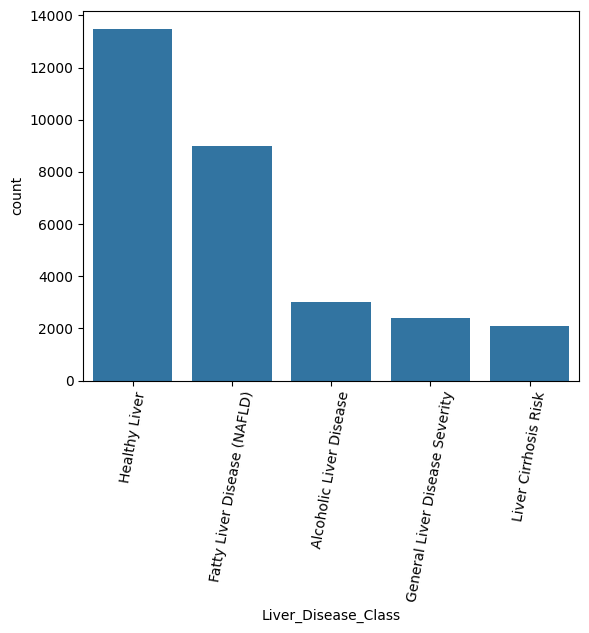

In [85]:
sns.barplot(x=df_training['Liver_Disease_Class'].value_counts().index,y=df_training['Liver_Disease_Class'].value_counts())
plt.xticks(rotation=80)
plt.show()

The target variable exhibits a mild class imbalance, with Healthy Liver representing the largest proportion (45%), while other liver disease categories are moderately underrepresented. Therefore, evaluation metrics beyond accuracy, such as F1-score, are required to ensure fair performance across all classes.

### Studying features distributions

This section explores the distribution of features to understand their ranges, detect potential anomalies, and gain insights into the underlying patterns within the dataset before model training.

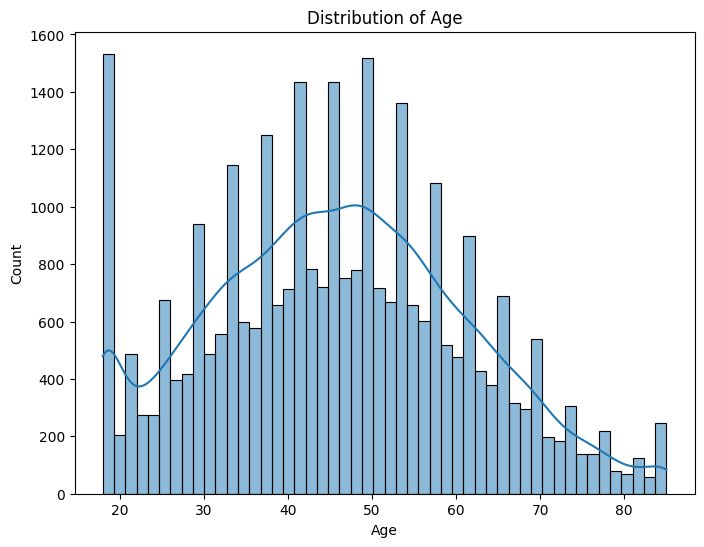

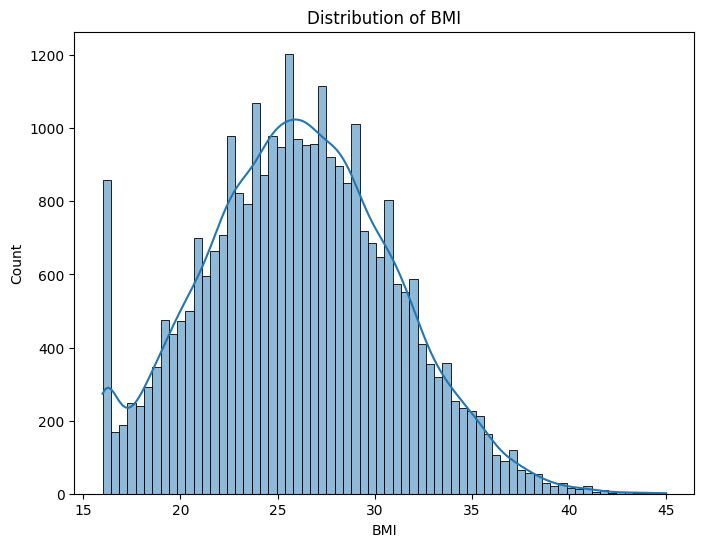

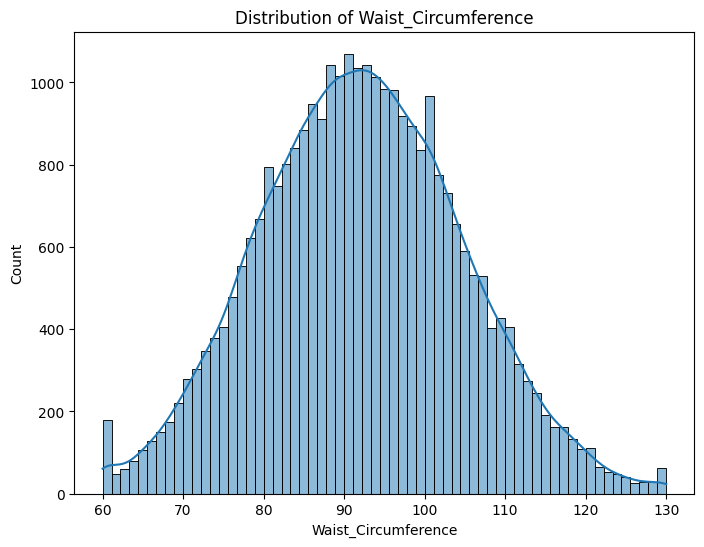

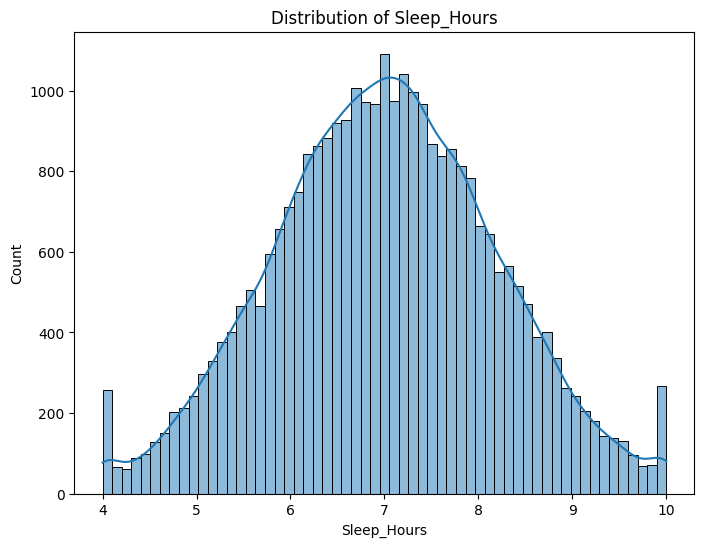

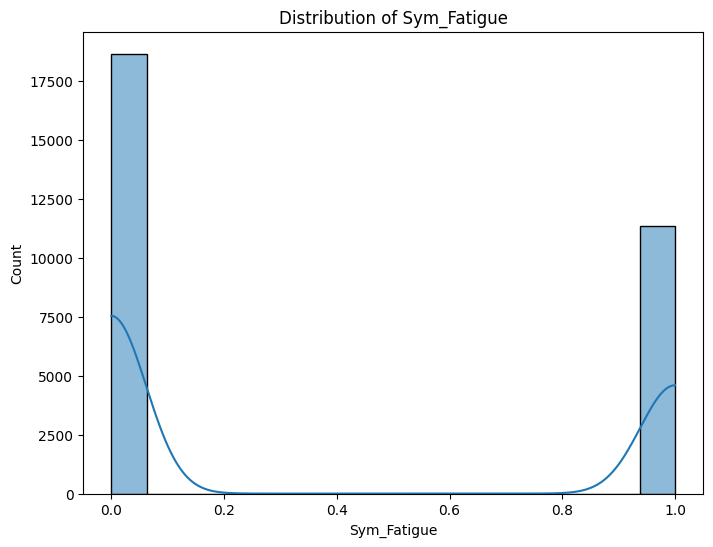

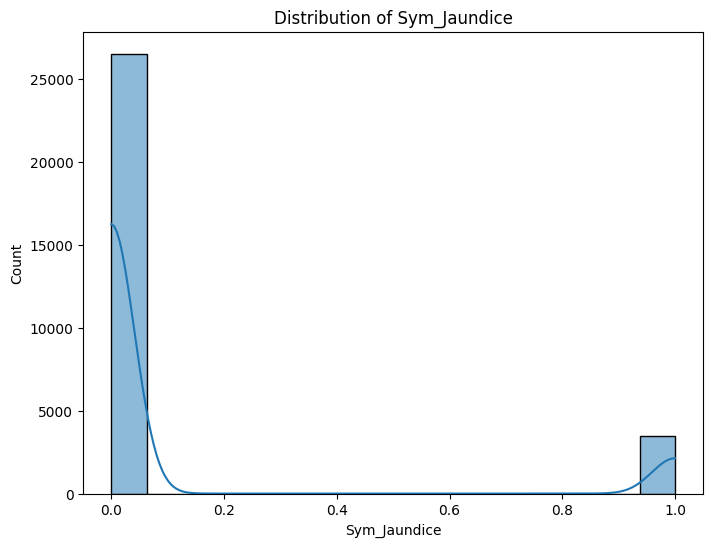

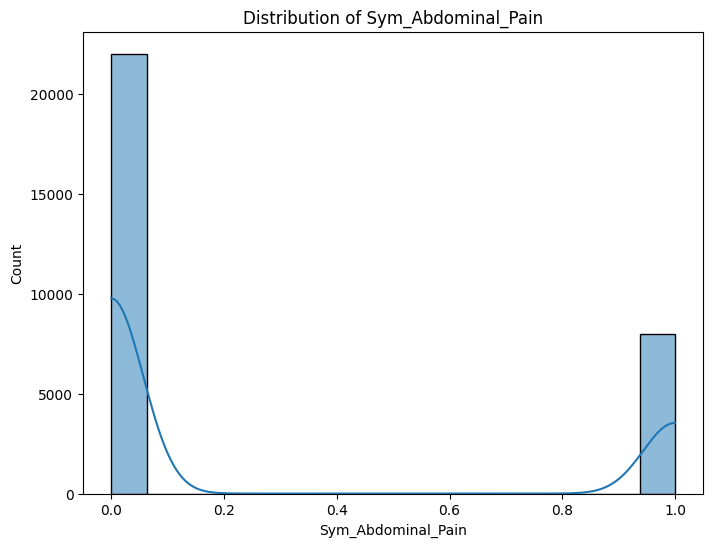

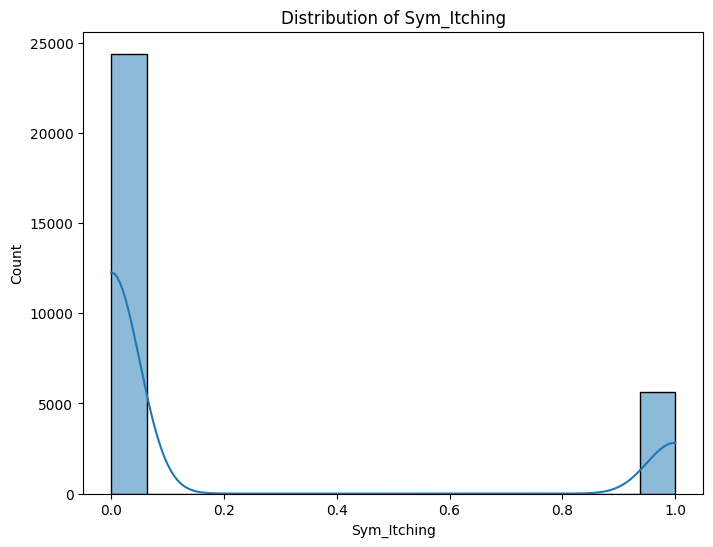

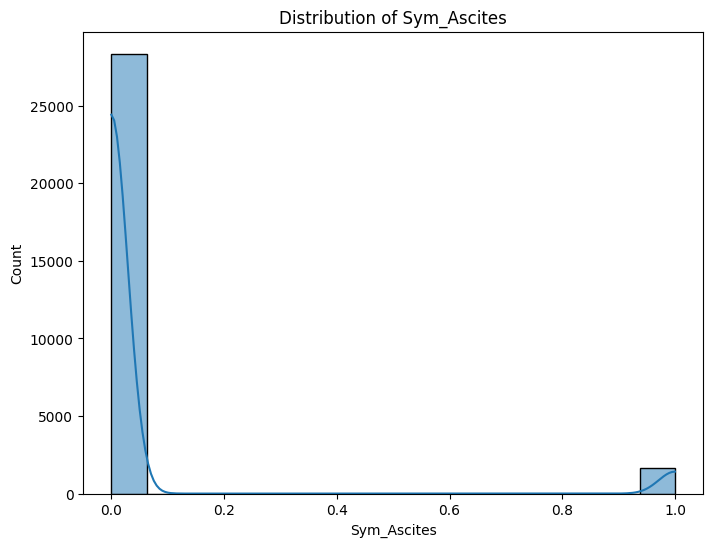

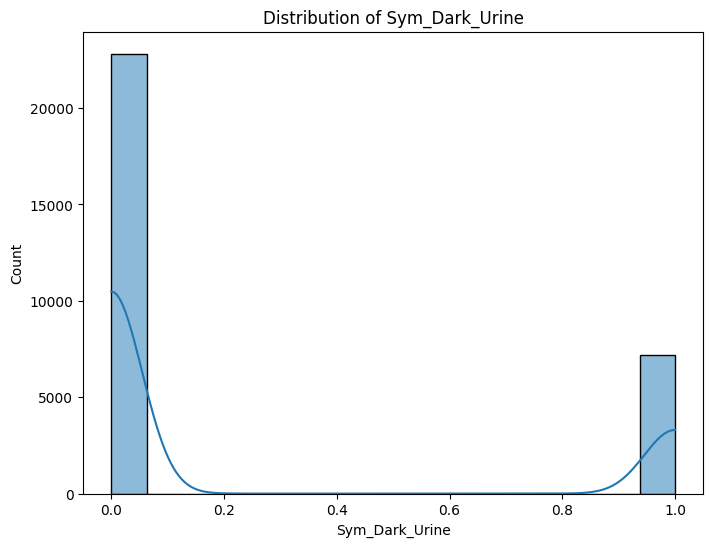

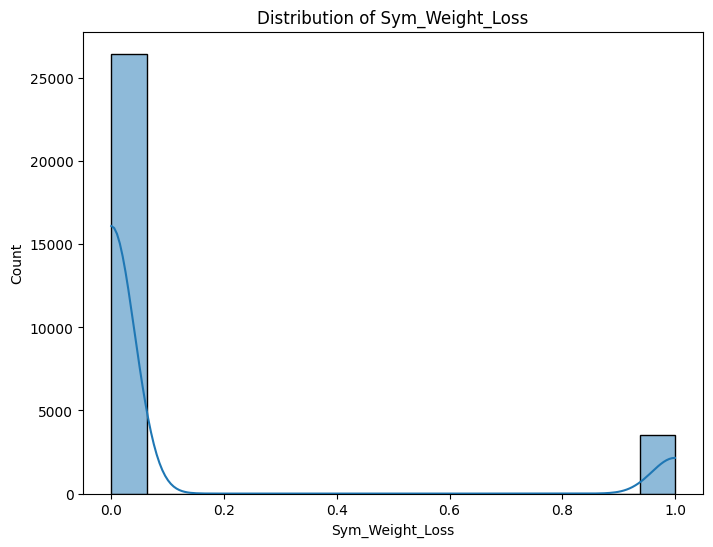

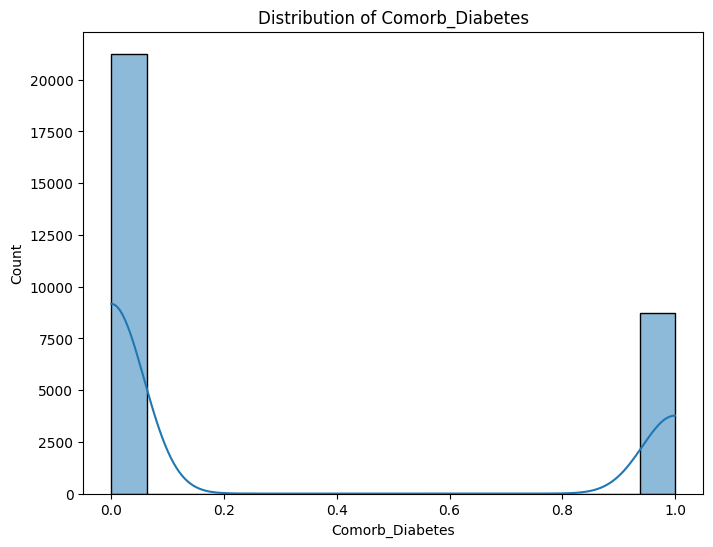

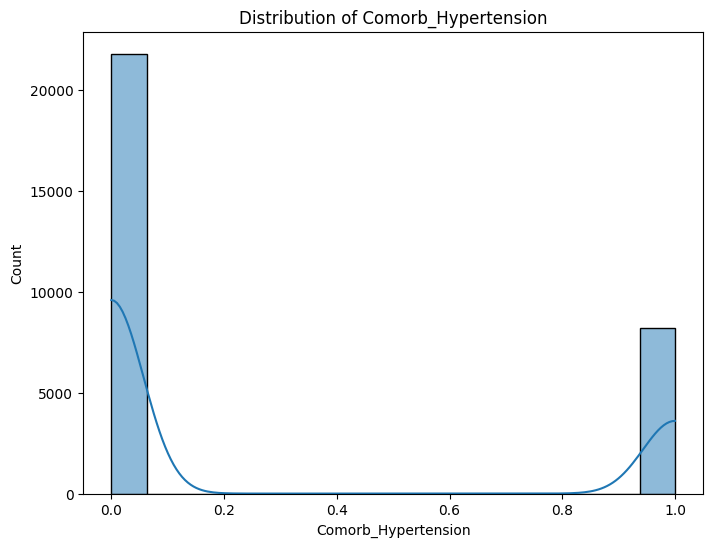

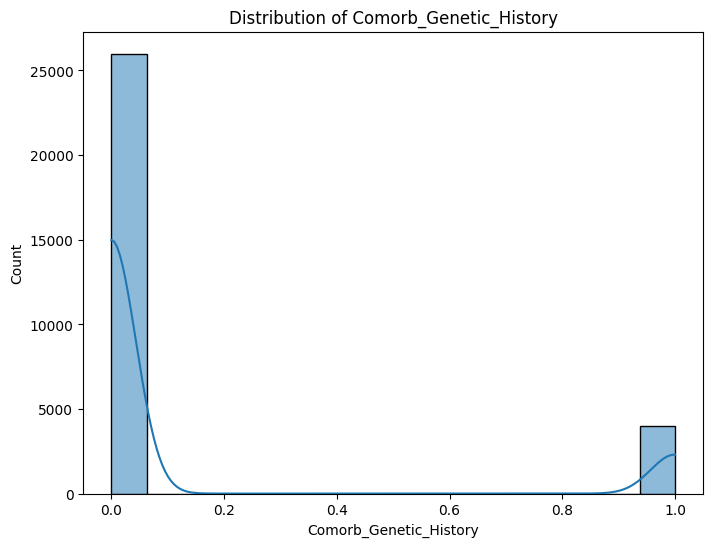

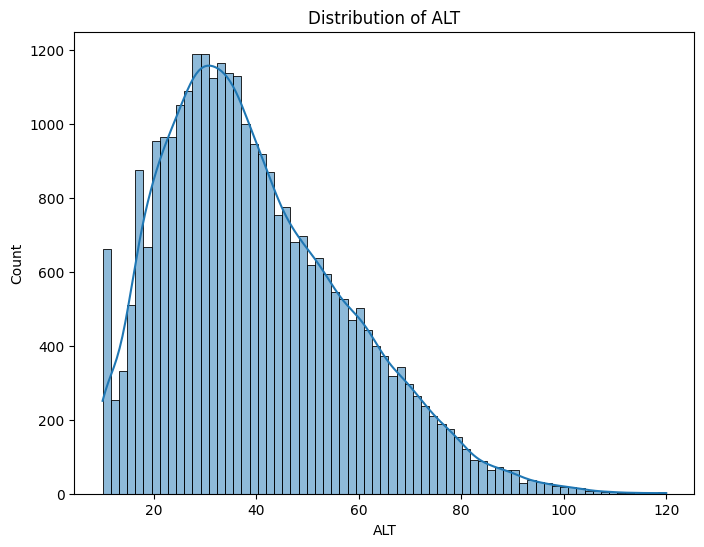

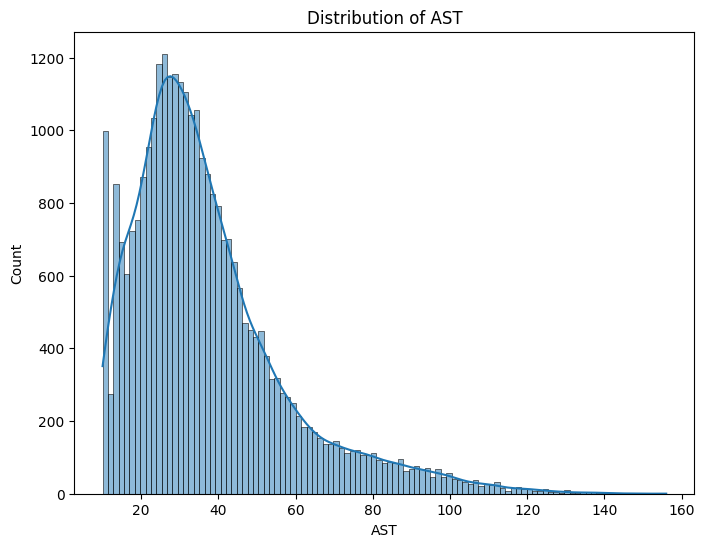

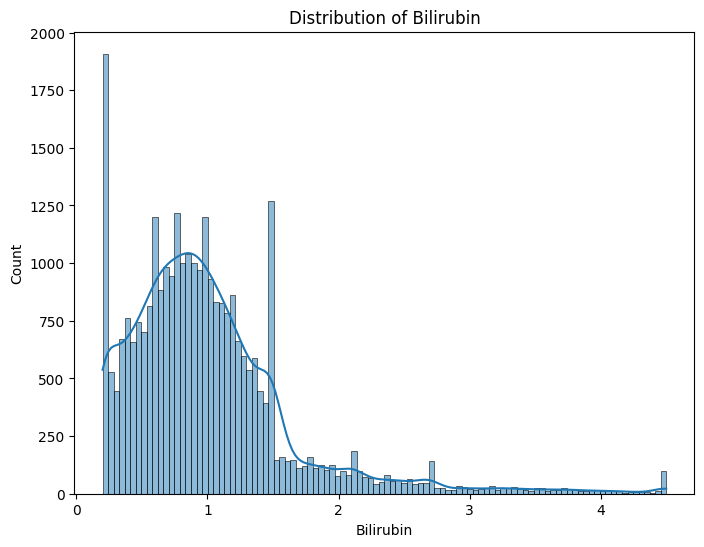

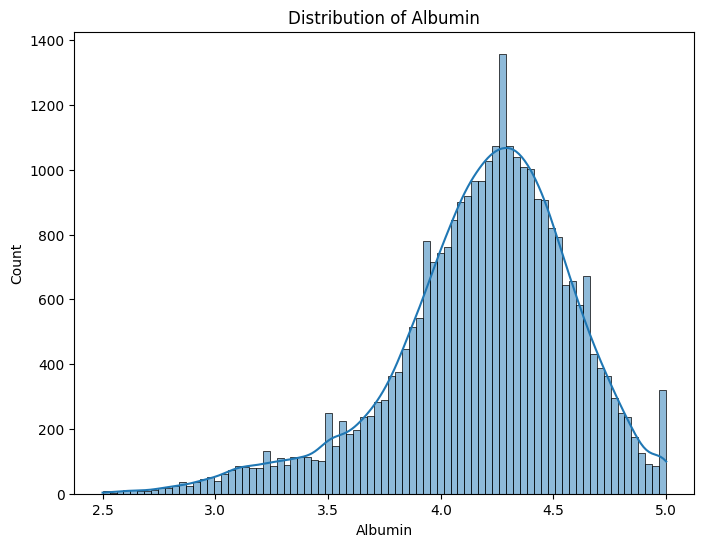

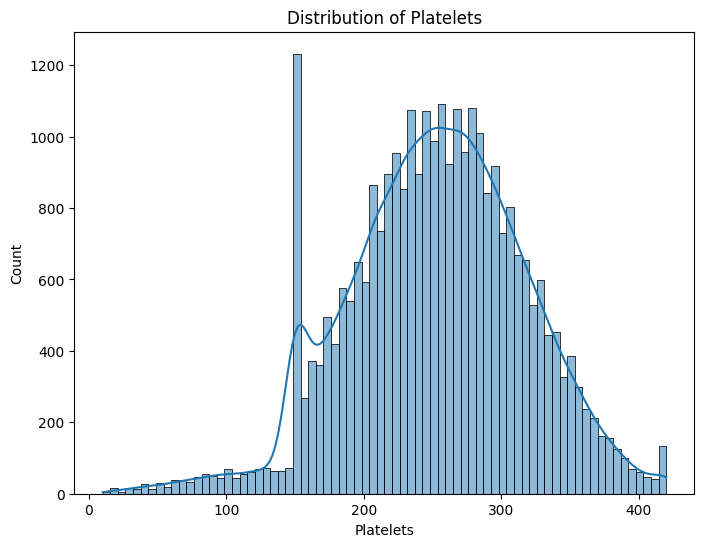

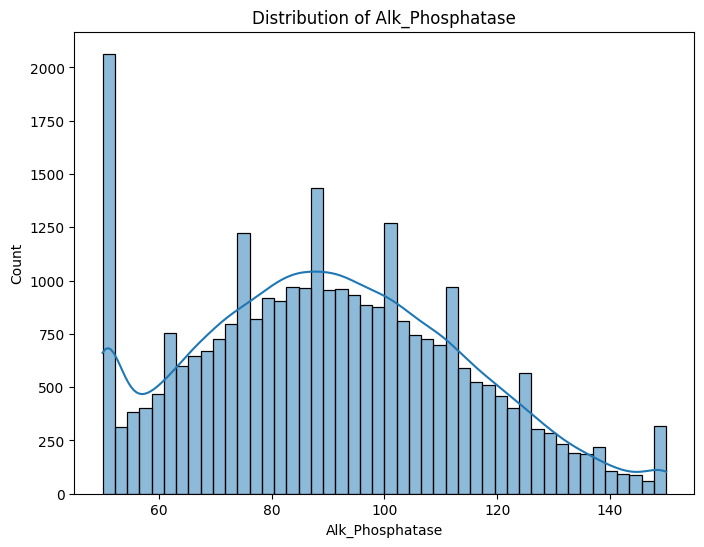

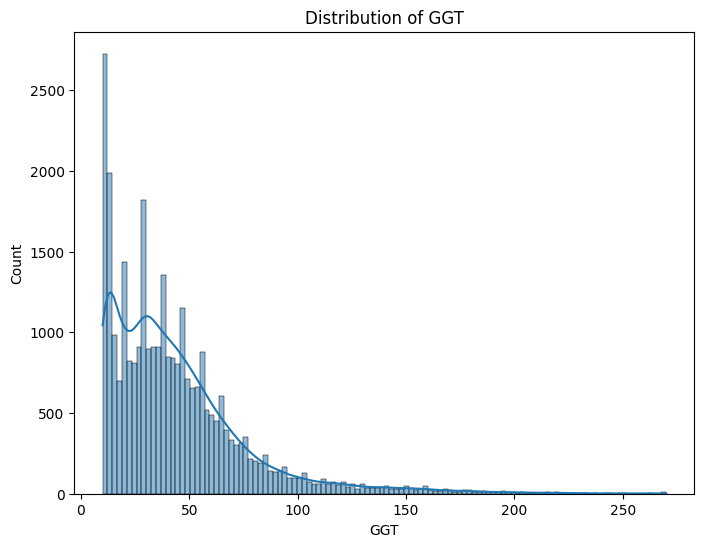

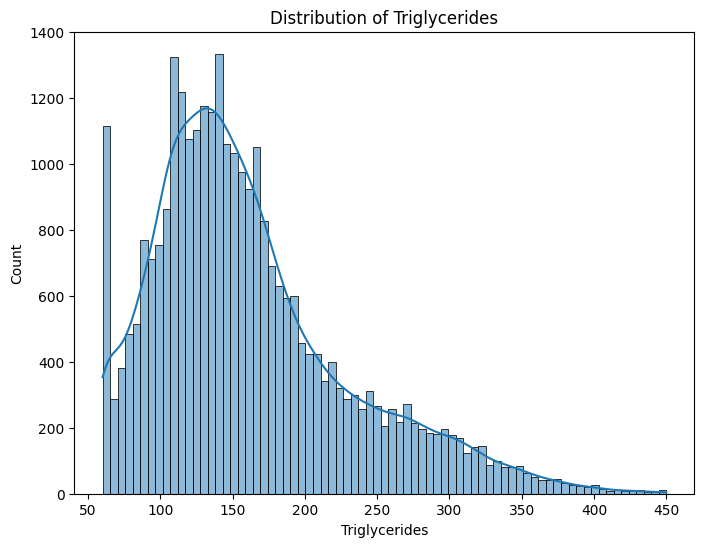

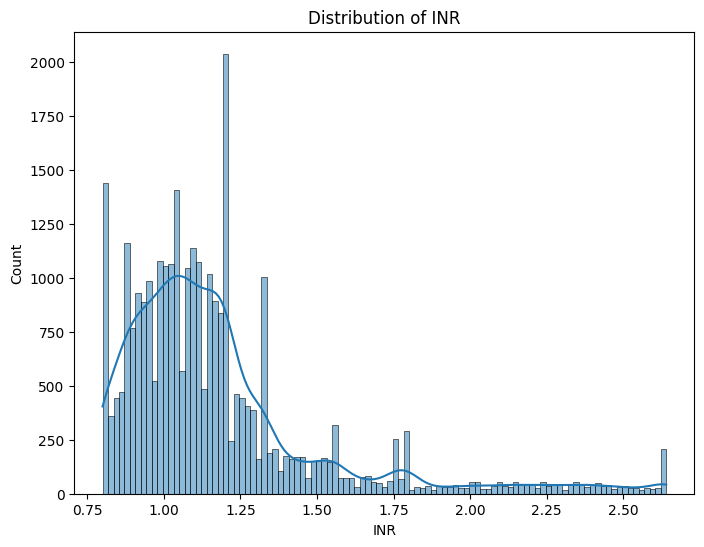

In [87]:
numeric_features = df_training.select_dtypes(exclude="object").columns
for col in numeric_features:
    plt.figure(figsize=(8, 6))
    sns.histplot(df_training[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

### Evaluating correlations between numerical variables using a correlation matrix.

Correlation analysis is performed to quantify pairwise relationships among numerical variables and to detect potential multicollinearity issues affecting model performance.

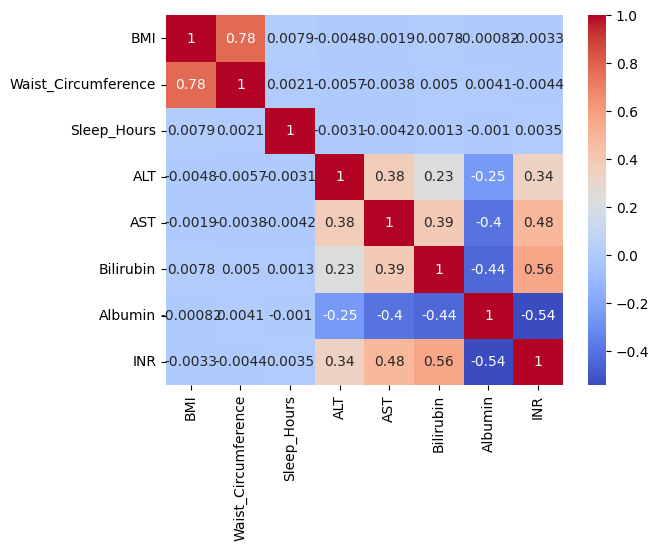

In [95]:
# computing pearson correlation for numeric features
numeric_features = df_training.select_dtypes(include="float64").columns
corr_matrix = df_training[numeric_features].corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

The correlation matrix shows generally low-to-moderate relationships between most features. A notable correlation is observed between BMI and Waist Circumference (0.78), indicating partial redundancy between these two obesity-related measures, which may lead to duplicated information in distance-based models like KNN. Most other features show weak to moderate correlations, suggesting limited multicollinearity across the dataset.

In [97]:
# dropping BMI col
df_training = df_training.drop(columns=['BMI'])

### Assessing categorical feature cardinality to guide encoding decisions.

## 1.3 Split
In this stage, the dataset was split into training, validation, and testing sets to ensure proper model evaluation and prevent overfitting.

The data was divided as follows:

- Training set: Used to train the machine learning models.
- Validation set: Used for hyperparameter tuning and model selection.
- Testing set: Used only once at the end to evaluate the final model performance on unseen data.

This separation ensures that the model is evaluated on unseen data and provides a reliable estimate of its generalization ability.

A stratified split was applied (when necessary) to preserve the distribution of the target variable across all subsets.

In [ ]:
target = ...
features = ...
# splitting data into training and validating sets
X_train, X_validation, y_train, y_validation = train_test_split(features, target, test_size=0.2, random_state=42)

# 🤖 **2.Build Model**

## 2.1 Baseline

## 2.2 Iterate

## 2.3 Evaluate

# 💡 **3.Communicate Results**

# **4.Model Serialization**

In [ ]:
joblib.dump(model, "model.pkl")